# Vietnamese Embedding Models — Document Retrieval Evaluation
## Dataset: [YuITC/Vietnamese-Legal-Documents](https://huggingface.co/datasets/YuITC/Vietnamese-Legal-Documents)

This notebook evaluates Vietnamese embedding models on a real Vietnamese legal document retrieval task.

### Dataset Structure
| Column | Description |
|---|---|
| `question` | Natural language query (Vietnamese legal question) |
| `context_list` | List of relevant document passages (ground-truth answers) |
| `qid` | Unique query ID |
| `cid` | List of corpus document IDs that are relevant |

### How Retrieval Evaluation Works
1. **Indexing**: All unique passages from `context_list` across the dataset are pooled into one corpus. It will be embedded by different models for evaluating.
2. **Query**: Each `question` is a query which will be embedded using the same indexing model.
3. **Retrieval**: Each model encodes queries, then semantic search by cosine similarity. Usually only take best-K results.
4. **Metrics**: Computed by comparing ranked results against `cid` of the ground truth passage.

### Retrieval Metrics
| Metric | What it measures |
|---|---|
| **nDCG@k** | Ranking quality of top-k results — the primary IR metric |
| **MAP@k** | Mean Average Precision — rewards early, complete retrieval |
| **MRR@k** | Mean Reciprocal Rank — how high is the first relevant doc? |
| **Recall@k** | Fraction of all relevant docs found in top-k |
| **Hit@k** | Probablity of atleast one relevant doc in top-k |

## 1. System Runtime Environments

In [1]:
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    
    
import sys
sys.path.append('./utils')
sys.path.append('./metrics')
from utils.load_dataset import load_huggingface_dataset
from metrics import MODELS, K_VALUES

PyTorch version : 2.11.0+cu130
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060 Laptop GPU


/home/ntdatwows2003/Documents/vi_embed_eval/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the Dataset

In this evaluation, we use `test` split for faster processing and less burden for hardware.

In [2]:
dataset_name = "YuITC/Vietnamese-Legal-Documents"

df = load_huggingface_dataset(dataset_name)

Loading YuITC/Vietnamese-Legal-Documents ...


DatasetDict({
    train: Dataset({
        features: ['question', 'context_list', 'qid', 'cid'],
        num_rows: 89261
    })
    test: Dataset({
        features: ['question', 'context_list', 'qid', 'cid'],
        num_rows: 29746
    })
})

Using split : 'test'
Rows        : 29,746
Columns     : ['question', 'context_list', 'qid', 'cid']


## 3. Build Relevance Benchmark Table

Remove `context_list` from the dataset for better performance and faster processing. All the unique passages from this field is already encoded inside vector database for retrieval.

Only `cid` is needed to compare model's prediction against ground truth.

In [3]:
# Modify dataframe to drop context_list column
df.drop(columns="context_list", inplace=True)

print(f"Total queries                : {len(df):,}")

Total queries                : 29,746


## 4. Define Models to Evaluate

In [4]:
print(f"Models to evaluate: {len(MODELS)}")
for m in MODELS:
    print(f"  • {m['label']}")

Models to evaluate: 3
  • AITeamVN
  • Paraphrase-mul-MiniLM-L12-v2
  • BGE-M3


## 5. Initialize Vector Database

In [5]:
import chromadb

client = chromadb.PersistentClient(path="./database")

## 6. Metric Functions

In [6]:
import numpy as np

def dcg_at_k(ranked_rel, k):
    return sum(r / np.log2(i + 2) for i, r in enumerate(ranked_rel[:k]))

def ndcg_at_k(ranked_rel, k, n_relevant):
    ideal = [1] * min(n_relevant, k) + [0] * max(0, k - n_relevant)
    idcg  = dcg_at_k(ideal, k)
    return dcg_at_k(ranked_rel, k) / idcg if idcg > 0 else 0.0

def map_at_k(ranked_rel, k, n_relevant):
    if n_relevant == 0:
        return 0.0
    hits = ap = 0
    for i, r in enumerate(ranked_rel[:k]):
        if r:
            hits += 1
            ap   += hits / (i + 1)
    return ap / min(n_relevant, k)

def mrr_at_k(ranked_rel, k):
    for i, r in enumerate(ranked_rel[:k]):
        if r:
            return 1.0 / (i + 1)
    return 0.0

def recall_at_k(ranked_rel, k, n_relevant):
    return sum(ranked_rel[:k]) / n_relevant if n_relevant > 0 else 0.0

def hit_at_k(ranked_rel, k, n_relevant):
    return 1.0 if 1 in ranked_rel[:k] and n_relevant > 0 else 0.0

def precision_at_k(ranked_rel, k):
    return sum(ranked_rel[:k]) / k if k > 0 else 0.0

def all_metrics_at_k(ranked_rel, k, n_relevant) -> dict[str, float]:
    return {
        f"nDCG@{k}"      : ndcg_at_k(ranked_rel, k, n_relevant),
        f"MAP@{k}"       : map_at_k(ranked_rel, k, n_relevant),
        f"MRR@{k}"       : mrr_at_k(ranked_rel, k),
        f"Recall@{k}"    : recall_at_k(ranked_rel, k, n_relevant),
        f"Hit@{k}"       : hit_at_k(ranked_rel, k, n_relevant),
        f"Precision@{k}" : precision_at_k(ranked_rel, k),
    }

print("Metric functions ready.")

Metric functions ready.


## 7. Run Retrieval Evaluation

In [7]:
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import pandas as pd
import time

try:
    from pyvi.ViTokenizer import tokenize as vi_tokenize
    print("pyvi loaded — Vietnamese word segmentation available.")
except ImportError:
    vi_tokenize = None
    print("⚠️  pyvi not found — models requiring it will be skipped.")

BATCH_SIZE = 64               # reduce if you hit OOM
CHUNK      = 256              # queries processed per similarity batch

all_results    = []   # one array to store avg metrics per model

for model in MODELS:
    print(f"\n{'='*65}")
    print(f"  {model['label']}  ({model['name']})")
    print(f"{'='*65}")

    if model.get("needs_pyvi") and vi_tokenize is None:
        print("  ⚠️  Skipping: pyvi is required but not installed.")
        continue
    
    collection = client.get_collection(model["label"])

    try:
        instances_metrics = []
        for r_idx, data in tqdm(df.iterrows(), total=len(df), desc="Queries processing"):
            # Number of relevant documents
            n_relevant = len(data['cid'])
            
            retrieve_results = collection.query(
                query_texts=[data['question']],
                n_results=10,
            )
            
            # Ranked relevant score from retrival results
            ranked_rel = list(map(lambda x: int(int(x) in data['cid']) , retrieve_results["ids"][0]))
            # print(ranked_rel)
            
            # All recorded metrics for this particular instance
            all_metrics = {metric: value for k in K_VALUES for metric, value in all_metrics_at_k(ranked_rel, k, n_relevant).items()}
                
            # Add the instance metrics into a list for the current evaluating model
            instances_metrics.append(all_metrics)
        
        
        # Average over all evaluated queries
        metrics_df = pd.DataFrame(instances_metrics)

        print("Model evaluation: \n")
        # print(f"  ✅  Done in {avg['encoding_time']}s")
        model_metrics = {"Model" : model["name"]}
        
        for k in K_VALUES:
            model_metrics[f"nDCG@{k}"] = float(np.round(metrics_df[f"nDCG@{k}"].mean(), 5))
            model_metrics[f"MAP@{k}"] = float(np.round(metrics_df[f"MAP@{k}"].mean(), 5))
            model_metrics[f"MRR@{k}"] = float(np.round(metrics_df[f"MRR@{k}"].mean(), 5))
            model_metrics[f"Recall@{k}"] = float(np.round(metrics_df[f"Recall@{k}"].mean(), 5))
            model_metrics[f"Hit@{k}"] = float(np.round(metrics_df[f"Hit@{k}"].mean(), 5))
            model_metrics[f"Precision@{k}"] = float(np.round(metrics_df[f"Precision@{k}"].mean(), 5))
            
            # Logging
            print(f"At cutoff k = {k}: ")
            print(f"*** nDCG@{k} = {model_metrics[f'nDCG@{k}']}, MAP@{k} = {model_metrics[f'MAP@{k}']}, MRR@{k} = {model_metrics[f'MRR@{k}']},  Recall@{k} = {model_metrics[f'Recall@{k}']}, Hit@{k} = {model_metrics[f'Hit@{k}']}, Precision@{k} = {model_metrics[f'Precision@{k}']} ***\n")
            
        all_results.append(model_metrics)
        print(f"{'='*65}")

    except Exception as e:
        print(f"  ❌  Error: {e}")
        import traceback; traceback.print_exc()

print("\n🎉 All models evaluated.")

pyvi loaded — Vietnamese word segmentation available.

  AITeamVN  (AITeamVN/Vietnamese_Embedding)


Queries processing: 100%|██████████| 29746/29746 [16:13<00:00, 30.56it/s]


Model evaluation: 

At cutoff k = 1: 
*** nDCG@1 = 0.57221, MAP@1 = 0.57221, MRR@1 = 0.57221,  Recall@1 = 0.54388, Hit@1 = 0.57221, Precision@1 = 0.57221 ***

At cutoff k = 5: 
*** nDCG@5 = 0.68651, MAP@5 = 0.64586, MRR@5 = 0.66603,  Recall@5 = 0.7871, Hit@5 = 0.81144, Precision@5 = 0.16972 ***

At cutoff k = 10: 
*** nDCG@10 = 0.70789, MAP@10 = 0.65534, MRR@10 = 0.67434,  Recall@10 = 0.85009, Hit@10 = 0.87222, Precision@10 = 0.0923 ***


  Paraphrase-mul-MiniLM-L12-v2  (sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1015.11it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Queries processing: 100%|██████████| 29746/29746 [10:10<00:00, 48.75it/s]


Model evaluation: 

At cutoff k = 1: 
*** nDCG@1 = 0.31261, MAP@1 = 0.31261, MRR@1 = 0.31261,  Recall@1 = 0.295, Hit@1 = 0.31261, Precision@1 = 0.31261 ***

At cutoff k = 5: 
*** nDCG@5 = 0.40584, MAP@5 = 0.3715, MRR@5 = 0.38858,  Recall@5 = 0.49163, Hit@5 = 0.51459, Precision@5 = 0.10594 ***

At cutoff k = 10: 
*** nDCG@10 = 0.43112, MAP@10 = 0.38217, MRR@10 = 0.39888,  Recall@10 = 0.56787, Hit@10 = 0.59168, Precision@10 = 0.06146 ***


  BGE-M3  (BAAI/bge-m3)


Queries processing: 100%|██████████| 29746/29746 [16:02<00:00, 30.91it/s]


Model evaluation: 

At cutoff k = 1: 
*** nDCG@1 = 0.61202, MAP@1 = 0.61202, MRR@1 = 0.61202,  Recall@1 = 0.58025, Hit@1 = 0.61202, Precision@1 = 0.61202 ***

At cutoff k = 5: 
*** nDCG@5 = 0.72173, MAP@5 = 0.68193, MRR@5 = 0.70471,  Recall@5 = 0.81695, Hit@5 = 0.84327, Precision@5 = 0.17672 ***

At cutoff k = 10: 
*** nDCG@10 = 0.73992, MAP@10 = 0.69006, MRR@10 = 0.71158,  Recall@10 = 0.87059, Hit@10 = 0.89427, Precision@10 = 0.0948 ***


🎉 All models evaluated.


## 7. Results Summary

In [8]:
metric_cols = [f"{m}@{k}" for m in ["nDCG", "MAP", "MRR", "Recall", "Hit", "Precision"] for k in K_VALUES]

results_df = (
    pd.DataFrame(all_results)[["Model"] + metric_cols ]
    .sort_values("nDCG@10", ascending=False)
    .reset_index(drop=True)
)
results_df.index += 1
results_df.index.name = "Rank"

print("=" * 70)
print("  YuITC/Vietnamese-Legal-Documents — Retrieval Evaluation")
print("=" * 70)
results_df

  YuITC/Vietnamese-Legal-Documents — Retrieval Evaluation


,Model,nDCG@1,nDCG@5,nDCG@10,MAP@1,MAP@5,MAP@10,MRR@1,MRR@5,MRR@10,Recall@1,Recall@5,Recall@10,Hit@1,Hit@5,Hit@10,Precision@1,Precision@5,Precision@10
Rank,,,,,,,,,,,,,,,,,,,
1,BAAI/bge-m3,0.61202,0.72173,0.73992,0.61202,0.68193,0.69006,0.61202,0.70471,0.71158,0.58025,0.81695,0.87059,0.61202,0.84327,0.89427,0.61202,0.17672,0.09480
2,AITeamVN/Vietnamese_Embedding,0.57221,0.68651,0.70789,0.57221,0.64586,0.65534,0.57221,0.66603,0.67434,0.54388,0.78710,0.85009,0.57221,0.81144,0.87222,0.57221,0.16972,0.09230
3,sentence-transformers/paraphrase-multilingual-...,0.31261,0.40584,0.43112,0.31261,0.37150,0.38217,0.31261,0.38858,0.39888,0.29500,0.49163,0.56787,0.31261,0.51459,0.59168,0.31261,0.10594,0.06146


In [9]:
# nDCG@k view
ndcg_df = results_df[["Model"] + [f"nDCG@{k}" for k in K_VALUES]]
print("nDCG@k (higher is better):")
ndcg_df

nDCG@k (higher is better):


,Model,nDCG@1,nDCG@5,nDCG@10
Rank,,,,
1,BAAI/bge-m3,0.61202,0.72173,0.73992
2,AITeamVN/Vietnamese_Embedding,0.57221,0.68651,0.70789
3,sentence-transformers/paraphrase-multilingual-...,0.31261,0.40584,0.43112


## 8. Visualizations

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#4C9BE8", "#F4845F", "#6BCB77", "#FFD166", "#C77DFF"]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=PALETTE)
models  = results_df["Model"].tolist()

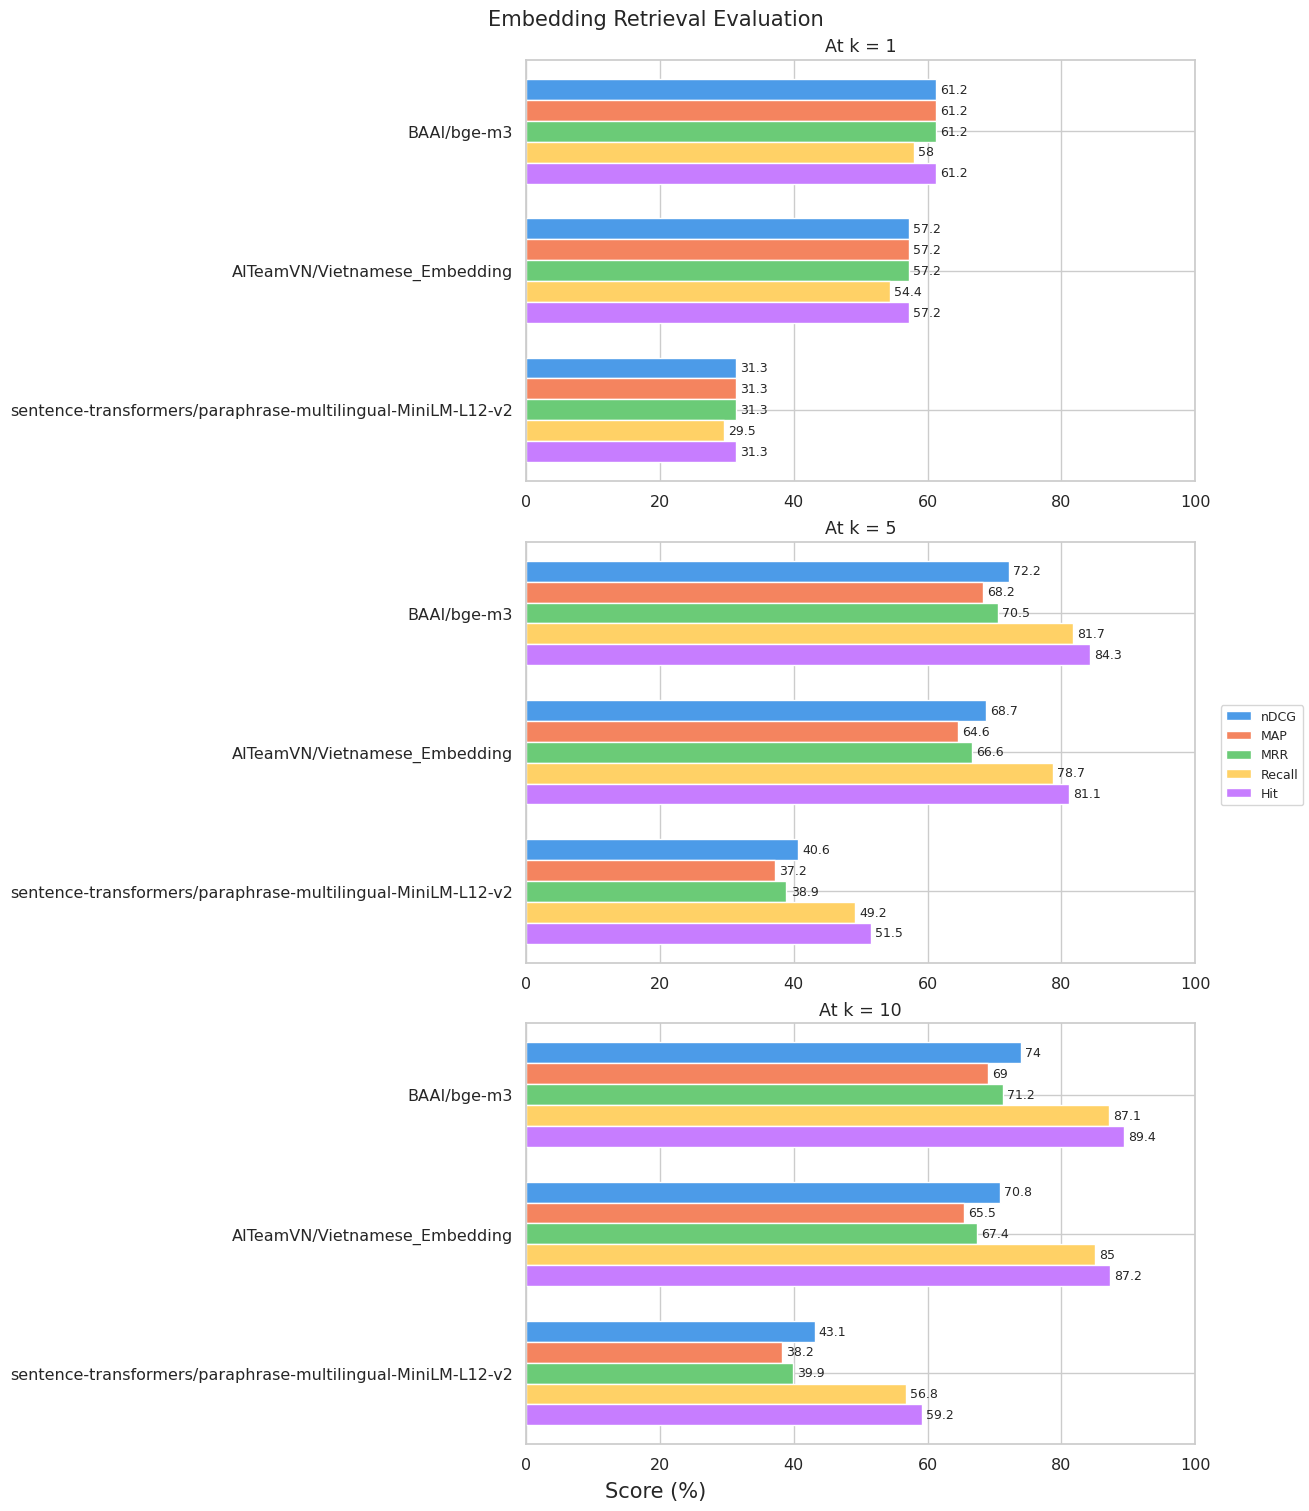

In [11]:
# ── Plot 1: Multi-metric bar chart at multiple k cutoffs

fig, axes = plt.subplots(len(K_VALUES), figsize=(13, 5*len(models)), layout='constrained')
y, height = np.arange(len(models)), 0.15

ax_idx = 0
for ax in axes:
    k = K_VALUES[ax_idx]
    focus = ["nDCG", "MAP", "MRR", "Recall", "Hit"]
    ax.invert_yaxis()
    
    for i, metric in enumerate(focus):
        bars = ax.barh(y + i * height, round(results_df[f"{metric}@{k}"]*100, 1), height=height, label = metric)  
        ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_yticks(y + height * (len(focus) - 1) / 2, models)
    ax.set_xlim(0, 100)
    
    ax.set_title(f"At k = {k}")
    # ax.legend(loc="upper right", fontsize=9)
    
    ax_idx += 1

handles, labels = plt.gca().get_legend_handles_labels()

fig.suptitle("Embedding Retrieval Evaluation")
fig.supxlabel("Score (%)")
fig.legend(handles=handles, labels=labels, loc="outside right center", fontsize=9)
plt.savefig("retrieval_benchmark.png", dpi=150)
plt.show()

In [ ]:
# ── Plot 2: nDCG@k line chart across cutoffs ──────────────────────
fig, axes = plt.subplots(figsize=(9, 5))

for i, (_, row) in enumerate(results_df.iterrows()):
    axes.plot(K_VALUES, [row[f"nDCG@{k}"] for k in K_VALUES],
            marker="o", label=row["Model"], color=PALETTE[i % len(PALETTE)])

axes.set_xlabel("k")
axes.set_ylabel("nDCG@k")
axes.set_title("nDCG@k Across Cutoffs — Vietnamese Legal Retrieval")
axes.set_xticks(K_VALUES)
axes.legend()
plt.tight_layout()
plt.savefig("ndcg_vs_k.png", dpi=150)
plt.show()

In [ ]:
# ── Plot 3: Heatmap ────────────────────────────────────────────────
heatmap_cols = [f"{m}@{k}"
                for m in ["nDCG", "MAP", "Recall", "MRR"]
                for k in [1, 5, 10]]
heat_data = results_df.set_index("Model")[heatmap_cols].astype(float)

fig, axes = plt.subplots(figsize=(13, len(models) * 0.9 + 1.5))
sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.4, ax=axes, cbar_kws={"label": "Score"})
axes.set_title("Retrieval Performance Heatmap — Vietnamese Legal Documents")
axes.set_xticklabels(axes.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("retrieval_heatmap.png", dpi=150)
plt.show()

## 11. Save Results

In [ ]:
results_df.to_csv("retrieval_results.csv")
hit_df.to_csv("hit_rate_results.csv")

for label, pq in per_query_all.items():
    safe = label.replace(" ", "_").replace("/","_").replace("(","").replace(")","")
    pq.to_csv(f"per_query_{safe}.csv", index=False)

print("Saved:")
print("  retrieval_results.csv   — aggregate metrics per model")
print("  hit_rate_results.csv    — Hit@k per model")
print("  per_query_<model>.csv   — per-query breakdown for each model")

---
## Quick Reference

| Setting | Where | Default |
|---|---|---|
| Number of queries to evaluate | Section 3 — `MAX_QUERIES` | `500` (set to `None` for all) |
| k cutoffs for metrics | Section 6 — `K_VALUES` | `[1, 5, 10, 20]` |
| Encoding batch size | Section 6 — `BATCH_SIZE` | `64` |
| Add / remove models | Section 4 — `MODELS` list | 5 models |

**Model guidance for Vietnamese legal retrieval:**
- `AITeamVN/Vietnamese_Embedding` — typically best for retrieval tasks; trained on Vietnamese triplets.
- `dangvantuan/vietnamese-document-embedding` — best if legal passages are long (supports 8096 tokens).
- `BAAI/bge-m3` — strong multilingual baseline; good if you later want cross-lingual retrieval.
- Inspect the `per_query_*.csv` files to understand failure patterns before choosing a model for production.